In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [42]:
from transformers import pipeline

## sentiment analysis

In [43]:
text_classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [44]:
text_classifier("i am very happy")

[{'label': 'POSITIVE', 'score': 0.9998795986175537}]

In [45]:
sentences = ["i am not sure what i am doing","they were not pleased by the performer","my day went as usual"]
text_classifier(sentences)

[{'label': 'NEGATIVE', 'score': 0.9996298551559448},
 {'label': 'NEGATIVE', 'score': 0.9997115731239319},
 {'label': 'POSITIVE', 'score': 0.8374792337417603}]

## zero shot classification

In [46]:
classifier = pipeline("zero-shot-classification")

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [47]:
classifier(
    "This is a code about Transformers piepline",  #input sentence
    candidate_labels=["education","programming","business"],  #will give confidence score for each of the label for input sentence
)

{'sequence': 'This is a code about Transformers piepline',
 'labels': ['programming', 'business', 'education'],
 'scores': [0.9604653120040894, 0.034619998186826706, 0.004914663266390562]}

## text generation

In [48]:
generator = pipeline("text-generation",model="gpt2")

Device set to use cpu


In [49]:
output = generator(
    "Cricket is a game of",
    max_new_tokens=20,
    do_sample=True,
    temperature=0.7,
    top_k=20,
    top_p=0.9
)
print(output[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Cricket is a game of tennis, where you can take a ball and score a set. It's a game where you're


In [50]:
sentences = ["I am making a sketch of stil objects","i like to see sunsets"]

output = generator(
    sentences,
    max_new_tokens=30,
    do_sample=True,
    temperature=0.7,
    top_k=20,
    top_p=0.9
)

for i,out in enumerate(output):
    print(f"\nInput : {sentences[i]}")
    print("Output : ",out[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Input : I am making a sketch of stil objects
Output :  I am making a sketch of stil objects. I am not making a sketch of the actual stil. I am making a sketch of the actual stil. I am making a sketch of

Input : i like to see sunsets
Output :  i like to see sunsets and sunrises.

"I want to make it as big as possible and I want it to be as beautiful as possible. I want to


## masked language modeling

In [51]:
fill_mask = pipeline("fill-mask", model="bert-base-uncased")

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [52]:
output = fill_mask("Chess is a [MASK] game")
for out in output:
    print(out["sequence"], " | score : ", out["score"])

chess is a board game  | score :  0.5134486556053162
chess is a chess game  | score :  0.31418442726135254
chess is a computer game  | score :  0.04106611758470535
chess is a card game  | score :  0.02488475665450096
chess is a video game  | score :  0.012677834369242191


## named entity recognition

In [53]:
ner = pipeline("ner", grouped_entities=True)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
/usr/local

In [54]:
sentence = "My name is Manthan and I work at XYZ in India since 2026."
output = ner(sentence)

for out in output:
    print(f"{out["word"]} : {out["entity_group"]}")

Manthan : PER
XYZ : ORG
India : LOC


## question answering

In [55]:
que_ans = pipeline("question-answering")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [56]:
context = "India is a vast and beautiful country in South Asia, known for its rich history, diverse cultures, and vibrant traditions.  It is the world's largest democracy, with a population of over 1.4 billion people. Home to the majestic Himalayas in the north and tropical beaches in the south, India boasts incredible geographical diversity. The nation celebrates unity in diversity, with 22 officially recognized languages, numerous religions, and a wide variety of festivals like Diwali, Holi, and Eid."
question = "What is the population of India?"

out = que_ans(question=question, context=context)
print(question)
print(out["answer"])

What is the population of India?
1.4 billion


## image classification

In [57]:
classifier = pipeline("image-classification")

No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326 (https://huggingface.co/google/vit-base-patch16-224).
Using a pipeline without specifying a model name and revision in production is not recommended.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


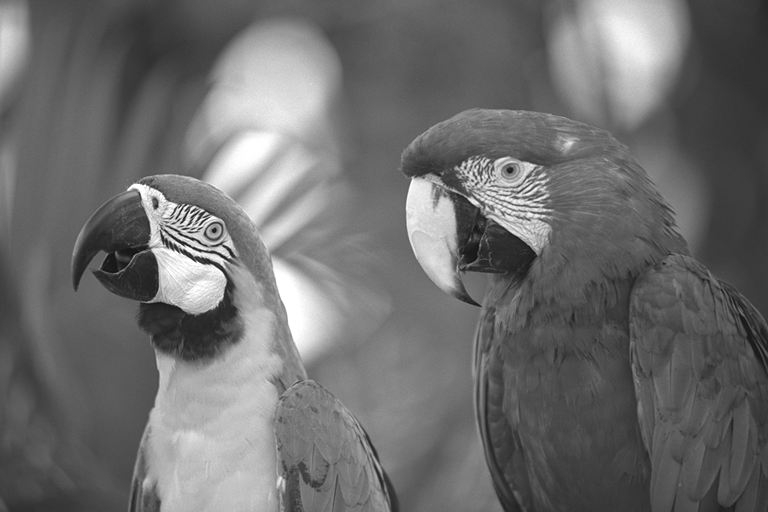

In [58]:
output = classifier("https://huggingface.co/datasets/Narsil/image_dummy/raw/main/parrots.png",top_k=3)

for pred in output:
    print(pred["label"], pred["score"])

macaw 0.9905233979225159
African grey, African gray, Psittacus erithacus 0.005603463854640722
toucan 0.0010569053702056408


## object detection

In [59]:
detector = pipeline("object-detection")

No model was supplied, defaulted to facebook/detr-resnet-50 and revision 1d5f47b (https://huggingface.co/facebook/detr-resnet-50).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a 

In [60]:
out = detector("https://huggingface.co/datasets/Narsil/image_dummy/raw/main/parrots.png")
for obj in out:
    print(obj["label"], obj["score"], obj["box"])

bird 0.9966394901275635 {'xmin': 69, 'ymin': 171, 'xmax': 396, 'ymax': 507}
bird 0.999381422996521 {'xmin': 398, 'ymin': 105, 'xmax': 767, 'ymax': 507}


No model was supplied, defaulted to facebook/detr-resnet-50 and revision 1d5f47b (https://huggingface.co/facebook/detr-resnet-50).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a 

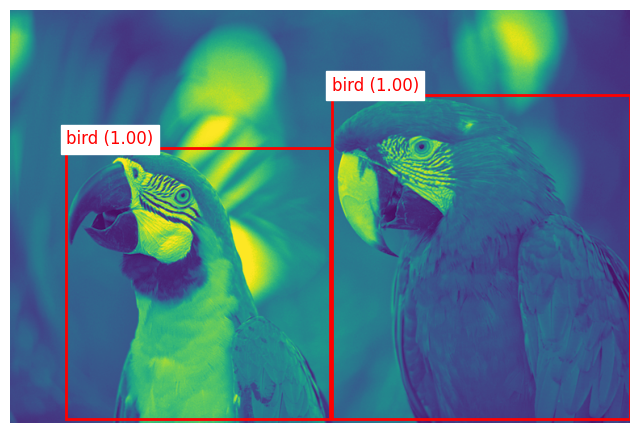

In [61]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Load detector
detector = pipeline("object-detection")

# Load image
url = "https://huggingface.co/datasets/Narsil/image_dummy/raw/main/parrots.png"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Detect objects
out = detector(img)

# Plot
plt.figure(figsize=(8,6))
plt.imshow(img)
ax = plt.gca()

for obj in out:
    box = obj["box"]
    label = obj["label"]
    score = obj["score"]

    # Draw rectangle
    rect = plt.Rectangle(
        (box["xmin"], box["ymin"]),
        box["xmax"] - box["xmin"],
        box["ymax"] - box["ymin"],
        fill=False,
        color="red",
        linewidth=2
    )
    ax.add_patch(rect)

    # Draw label
    ax.text(
        box["xmin"],
        box["ymin"] - 5,
        f"{label} ({score:.2f})",
        color="red",
        fontsize=12,
        backgroundcolor="white"
    )

plt.axis("off")
plt.show()

## visual question answering

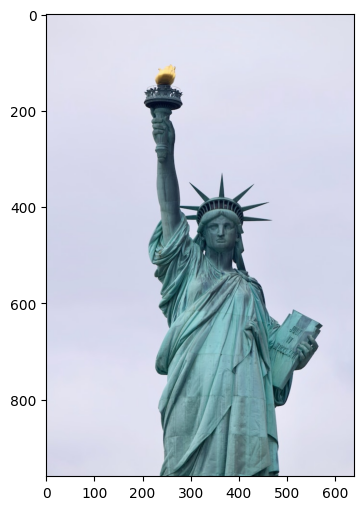

In [64]:
# Load image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/idefics-few-shot.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Plot
plt.figure(figsize=(6,6))
plt.imshow(img)

In [65]:
answer = pipeline(task="visual-question-answering", model="Salesforce/blip-vqa-base")
answer(
    image=img,
    question="What is in the image?",
)

Device set to use cpu


[{'answer': 'statue of liberty'}]